<a href="https://colab.research.google.com/github/altynaltyn/Final-ADA/blob/main/Data_Driven_Nutrition_Advisor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data-Driven Nutrition Advisor
This project builds weekly and monthly food baskets based on the
Harvard Healthy Plate model using local food prices and nutrition data.

Author: Kadyrbek Altynay




In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd

path = "/content/drive/MyDrive/ADA/nutrition_data.csv"
# Trying to read with semicolon delimiter and warning for bad lines
df = pd.read_csv(path, sep=';', on_bad_lines='warn')

df.head()

,Product Name,Store,Price,Package Weight in g,Calories per 100g,Protein per 100g,Fat per 100g,Carbs per 100g,category
0,Cucumbers Mirinda,Arbuz.kz,1 270,1000,15,0.8,0.1,"2,50",veg_fruit
1,Cucumbers Rava Green Land,Arbuz.kz,840,600,21,"1,24",0.35,"3,78",veg_fruit
2,Strawberry tomatoes,Arbuz.kz,775,500,20,0.8,"0,2","3,90",veg_fruit
3,Green asparagus,Arbuz.kz,2065,150,21,"1,90","0,1","3,10",veg_fruit
4,Mini carrots,Arbuz.kz,2015,520,35,"1,30","0,1","7,20",veg_fruit


In [3]:
def to_plate_group(cat: str) -> str:
    cat = str(cat).strip().lower()
    mapping = {
        "veg_fruit": "veg_fruit",
        "vegetables": "veg_fruit",

        "fish": "protein",
        "meat": "protein",
        "eggs": "protein",

        "pasta": "grains",
        "croats": "grains",

        "dairy": "dairy",
        "butter": "fats"
    }
    return mapping.get(cat, "other")

df["plate_group"] = df["category"].apply(to_plate_group)


In [4]:
def to_plate_group(cat: str) -> str:
    cat = str(cat).strip().lower()
    mapping = {
        "veg_fruit": "veg_fruit",
        "vegetables": "veg_fruit",

        "protein": "protein",
        "fish": "protein",
        "meat": "protein",
        "eggs": "protein",

        "grains": "grains",
        "pasta": "grains",
        "croats": "grains",

        "dairy": "dairy",
        "butter": "fats"
    }
    return mapping.get(cat, "other")

df["plate_group"] = df["category"].apply(to_plate_group)
df["plate_group"].value_counts()


,count
plate_group,
veg_fruit,61
protein,49
grains,25
dairy,24
fats,3


In [25]:
import numpy as np
import pandas as pd

# 1) Price: убираем пробелы и запятые, делаем число
df["Price"] = (df["Price"].astype(str)
               .str.replace(" ", "", regex=False)
               .str.replace(",", ".", regex=False))
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

# 2) Package Weight: оставляем только число (например "15pcs" -> 15)
df["Package Weight in g"] = (df["Package Weight in g"].astype(str)
                             .str.replace(" ", "", regex=False)
                             .str.replace(",", ".", regex=False)
                             .str.extract(r"(\d+\.?\d*)", expand=False))
df["Package Weight in g"] = pd.to_numeric(df["Package Weight in g"], errors="coerce")

# 3) Clean and convert nutritional columns to numeric
nutrition_cols = [
    "Calories per 100g",
    "Protein per 100g",
    "Fat per 100g",
    "Carbs per 100g",
]
for col in nutrition_cols:
    df[col] = (df[col].astype(str)
               .str.replace(" ", "", regex=False)
               .str.replace(",", ".", regex=False))
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Проверим проблемные строки (original check, keep for other columns if needed)
df[df["Package Weight in g"].isna()][["Product Name", "Package Weight in g"]].head(10)

# price per 100g (если ещё не делала)
df["price_per_100g"] = df["Price"] / df["Package Weight in g"] * 100
TARGETS = {"veg_fruit": 0.50, "grains": 0.25, "protein": 0.25}

def build_week_basket(df, days=7, grams_per_day=1200, tier="budget", n_items_per_group=5, seed=42):
    np.random.seed(seed)
    total_g = days * grams_per_day

    rows = []
    for group, share in TARGETS.items():
        need_g = total_g * share

        gdf = df[df["plate_group"] == group].dropna(subset=["price_per_100g", "Price", "Package Weight in g"])
        if len(gdf) == 0:
            print(f"⚠️ No items for group: {group}")
            continue

        # выбор по tier
        if tier == "budget":
            items = gdf.sort_values("price_per_100g").head(n_items_per_group)
        elif tier == "premium":
            items = gdf.sort_values("price_per_100g").tail(n_items_per_group)
        else:  # standard
            items = gdf.sort_values("price_per_100g").head(n_items_per_group*2).sample(n_items_per_group, random_state=seed)

        grams_each = need_g / len(items)

        for _, r in items.iterrows():
            grams = grams_each
            pack_w = r["Package Weight in g"]
            packages = int(np.ceil(grams / pack_w))
            cost = packages * r["Price"]

            rows.append({
                "plate_group": group,
                "Product Name": r["Product Name"],
                "Store": r["Store"],
                "grams_needed_week": round(grams, 0),
                "package_weight_g": pack_w,
                "packages_to_buy": packages,
                "price_kzt": r["Price"],
                "cost_kzt": cost,
                "price_per_100g": round(r["price_per_100g"], 2),
            })

    basket = pd.DataFrame(rows).sort_values(["plate_group", "cost_kzt"], ascending=[True, False])
    total_cost = basket["cost_kzt"].sum()

    return basket, total_cost

basket_budget, cost_budget = build_week_basket(df, days=7, grams_per_day=1200, tier="budget")
basket_budget, cost_budget

(   plate_group                                       Product Name     Store  \
 8       grains                            Buckwheat makfa nucleus  Arbuz.kz   
 9       grains                         Рис Arbuz select для плова  Arbuz.kz   
 7       grains                       Крупа Arbuz select гречневая  Arbuz.kz   
 6       grains                  Крупа Arbuz select горох колотый   Arbuz.kz   
 5       grains                          Крупа Arbuz select манная  Arbuz.kz   
 12     protein  Wing alfur shoulder part of the chicken-broile...  Arbuz.kz   
 11     protein  Kus Vkus chicken thigh broiler on the substrat...  Arbuz.kz   
 14     protein                Arbuz Select Chilled Chicken wings   Arbuz.kz   
 13     protein                 Arbuz Select Chilled Chicken Thigh  Arbuz.kz   
 10     protein                  Arbuz Select Frozen Chicken Thigh  Arbuz.kz   
 3    veg_fruit                                  Pumpkin chamomile  Arbuz.kz   
 2    veg_fruit                       Ка

In [9]:
print("Total cost (Budget, 7 days):", round(cost_budget, 0), "KZT")
basket_budget.groupby("plate_group")[["grams_needed_week","cost_kzt"]].sum()


Total cost (Budget, 7 days): 14026.0 KZT


,grams_needed_week,cost_kzt
plate_group,,
grains,2100.0,2667.0
protein,2100.0,8303.0
veg_fruit,4200.0,3056.0


In [18]:
basket_std, cost_std = build_week_basket(df, tier="standard")
basket_prem, cost_prem = build_week_basket(df, tier="premium")


In [19]:
def filter_premium(gdf, group):
    """
    Avoid unrealistic premium baskets caused by very small package sizes.
    For weekly baskets, exclude too small packages for vegetables/fruits.
    """
    if group == "veg_fruit":
        return gdf[gdf["Package Weight in g"] >= 300]
    return gdf


In [20]:
import numpy as np
import pandas as pd

df["price_per_100g"] = df["Price"] / df["Package Weight in g"] * 100

TARGETS = {"veg_fruit": 0.50, "grains": 0.25, "protein": 0.25}

def pick_items(gdf, tier, n, seed=42):
    np.random.seed(seed)

    if tier == "budget":
        return gdf.sort_values("price_per_100g").head(n)

    if tier == "standard":
        return gdf.sort_values("price_per_100g").head(n*2).sample(n, random_state=seed)

    # PREMIUM = best value, not most expensive
    if tier == "premium":
        if "Protein per 100g" in gdf.columns:
            # maximize nutrition per price
            gdf = gdf.copy()
            gdf["value_score"] = (
                gdf["Protein per 100g"] / gdf["price_per_100g"]
            )
            return gdf.sort_values("value_score", ascending=False).head(n)
        else:
            # fallback
            return gdf.sort_values("price_per_100g").tail(n)

    return gdf.head(n)


def build_basket(
    df,
    days=7,
    grams_per_day=1200,
    tier="budget",
    n_items_per_group=5,
    add_dairy=True,
    dairy_g_per_day=200,
    add_fats=True,
    fats_g_per_day=15,
    seed=42
):
    np.random.seed(seed)
    rows = []

    # --- main plate groups 50/25/25 ---
    total_g = days * grams_per_day

    for group, share in TARGETS.items():
        need_g = total_g * share
        gdf = df[df["plate_group"] == group].dropna(subset=["price_per_100g", "Price", "Package Weight in g"])
        # premium realism fix
        if tier == "premium":
          gdf = filter_premium(gdf, group)

        items = pick_items(gdf, tier, n_items_per_group, seed)

        grams_each = need_g / len(items)

        for _, r in items.iterrows():
            pack_w = r["Package Weight in g"]
            packages = int(np.ceil(grams_each / pack_w))
            cost = packages * r["Price"]

            rows.append({
                "plate_group": group,
                "Product Name": r["Product Name"],
                "Store": r["Store"],
                "grams_needed": round(grams_each, 0),
                "package_weight_g": pack_w,
                "packages_to_buy": packages,
                "price_kzt": r["Price"],
                "cost_kzt": cost,
                "price_per_100g": round(r["price_per_100g"], 2),
            })

    # --- optional dairy ---
    if add_dairy:
        need_g = days * dairy_g_per_day
        gdf = df[df["plate_group"] == "dairy"].dropna(subset=["price_per_100g", "Price", "Package Weight in g"])
        if len(gdf) > 0:
            items = pick_items(gdf, tier, n=3, seed=seed)
            grams_each = need_g / len(items)
            for _, r in items.iterrows():
                pack_w = r["Package Weight in g"]
                packages = int(np.ceil(grams_each / pack_w))
                cost = packages * r["Price"]
                rows.append({
                    "plate_group": "dairy",
                    "Product Name": r["Product Name"],
                    "Store": r["Store"],
                    "grams_needed": round(grams_each, 0),
                    "package_weight_g": pack_w,
                    "packages_to_buy": packages,
                    "price_kzt": r["Price"],
                    "cost_kzt": cost,
                    "price_per_100g": round(r["price_per_100g"], 2),
                })

    # --- optional fats ---
    if add_fats:
        need_g = days * fats_g_per_day
        gdf = df[df["plate_group"] == "fats"].dropna(subset=["price_per_100g", "Price", "Package Weight in g"])
        if len(gdf) > 0:
            items = pick_items(gdf, tier, n=1, seed=seed)  # butter/oil usually 1 item enough
            grams_each = need_g
            for _, r in items.iterrows():
                pack_w = r["Package Weight in g"]
                packages = int(np.ceil(grams_each / pack_w))
                cost = packages * r["Price"]
                rows.append({
                    "plate_group": "fats",
                    "Product Name": r["Product Name"],
                    "Store": r["Store"],
                    "grams_needed": round(grams_each, 0),
                    "package_weight_g": pack_w,
                    "packages_to_buy": packages,
                    "price_kzt": r["Price"],
                    "cost_kzt": cost,
                    "price_per_100g": round(r["price_per_100g"], 2),
                })

    basket = pd.DataFrame(rows).sort_values(["plate_group", "cost_kzt"], ascending=[True, False])
    total_cost = float(basket["cost_kzt"].sum())
    return basket, total_cost


In [26]:
basket_budget, cost_budget = build_basket(df, days=7, tier="budget")
basket_std, cost_std = build_basket(df, days=7, tier="standard")
basket_prem, cost_premium = build_basket(df, days=7, tier="premium")

print("Budget:", round(cost_budget), "KZT")
print("Standard:", round(cost_std), "KZT")
print("Premium:", round(cost_premium), "KZT")


Budget: 16975 KZT
Standard: 21868 KZT
Premium: 28647 KZT


In [27]:
def basket_summary(basket):
    s = basket.groupby("plate_group")[["grams_needed","cost_kzt"]].sum().sort_values("cost_kzt", ascending=False)
    s["cost_share_%"] = (s["cost_kzt"] / s["cost_kzt"].sum() * 100).round(1)
    return s

basket_summary(basket_budget)


,grams_needed,cost_kzt,cost_share_%
plate_group,,,
protein,2100.0,8303.0,48.9
veg_fruit,4200.0,3056.0,18.0
grains,2100.0,2667.0,15.7
dairy,1401.0,1604.0,9.4
fats,105.0,1345.0,7.9


In [29]:
basket_prem.sort_values("cost_kzt", ascending=False).head(15)[
    ["plate_group","Product Name","package_weight_g","packages_to_buy","price_kzt","cost_kzt","price_per_100g"]
]

,plate_group,Product Name,package_weight_g,packages_to_buy,price_kzt,cost_kzt,price_per_100g
10,protein,KazBeef minced marbled beef 80/20 frozen,1000.0,1,5980.0,5980.0,598.00
17,dairy,Belebeevsky cheese 190 g,347.0,2,1820.0,3640.0,524.50
14,protein,Arbuz Select frozen chicken fillet,700.0,1,2055.0,2055.0,293.57
11,protein,Wing alfur shoulder part of the chicken-broile...,1000.0,1,2016.0,2016.0,201.60
3,veg_fruit,Pumpkin chamomile,7500.0,1,1950.0,1950.0,26.00
13,protein,Kus Vkus chicken thigh broiler on the substrat...,1000.0,1,1921.0,1921.0,192.10
15,dairy,Cottage cheese President homemade 5%,450.0,2,915.0,1830.0,203.33
16,dairy,Cottage cheese Adal Products of our farms Trad...,200.0,3,485.0,1455.0,242.50
18,fats,Butter Brest-Litovsk unsalted sweet 82.5%,180.0,1,1345.0,1345.0,747.22
12,protein,Arbuz Select Frozen Chicken Thigh,700.0,1,1152.0,1152.0,164.57


In [30]:
def shopping_list(basket):
    cols = [
        "plate_group",
        "Product Name",
        "Store",
        "packages_to_buy",
        "price_kzt",
        "cost_kzt"
    ]
    sl = basket[cols].copy()
    sl = sl.rename(columns={
        "plate_group": "Group",
        "packages_to_buy": "Packages",
        "price_kzt": "Price (KZT)",
        "cost_kzt": "Total Cost (KZT)"
    })
    return sl.sort_values(["Group", "Total Cost (KZT)"], ascending=[True, False])

shopping_list(basket_budget)


,Group,Product Name,Store,Packages,Price (KZT),Total Cost (KZT)
15,dairy,Kefir Food Master 2.5,Arbuz.kz,1,643.0,643.0
16,dairy,Ayran Lyazzat,Arbuz.kz,2,250.0,500.0
17,dairy,Kefir Amiran live 2.5%,Arbuz.kz,1,461.0,461.0
18,fats,Butter Brest-Litovsk unsalted sweet 82.5%,Arbuz.kz,1,1345.0,1345.0
8,grains,Buckwheat makfa nucleus,Arbuz.kz,1,719.0,719.0
9,grains,Рис Arbuz select для плова,Arbuz.kz,1,655.0,655.0
7,grains,Крупа Arbuz select гречневая,Arbuz.kz,1,499.0,499.0
6,grains,Крупа Arbuz select горох колотый,Arbuz.kz,1,399.0,399.0
5,grains,Крупа Arbuz select манная,Arbuz.kz,1,395.0,395.0
12,protein,Wing alfur shoulder part of the chicken-broile...,Arbuz.kz,1,2016.0,2016.0


In [31]:
for group, gdf in shopping_list(basket_budget).groupby("Group"):
    print(f"\n🟢 {group.upper()}")
    display(gdf.drop(columns=["Group"]))



🟢 DAIRY


,Product Name,Store,Packages,Price (KZT),Total Cost (KZT)
15,Kefir Food Master 2.5,Arbuz.kz,1,643.0,643.0
16,Ayran Lyazzat,Arbuz.kz,2,250.0,500.0
17,Kefir Amiran live 2.5%,Arbuz.kz,1,461.0,461.0



🟢 FATS


,Product Name,Store,Packages,Price (KZT),Total Cost (KZT)
18,Butter Brest-Litovsk unsalted sweet 82.5%,Arbuz.kz,1,1345.0,1345.0



🟢 GRAINS


,Product Name,Store,Packages,Price (KZT),Total Cost (KZT)
8,Buckwheat makfa nucleus,Arbuz.kz,1,719.0,719.0
9,Рис Arbuz select для плова,Arbuz.kz,1,655.0,655.0
7,Крупа Arbuz select гречневая,Arbuz.kz,1,499.0,499.0
6,Крупа Arbuz select горох колотый,Arbuz.kz,1,399.0,399.0
5,Крупа Arbuz select манная,Arbuz.kz,1,395.0,395.0



🟢 PROTEIN


,Product Name,Store,Packages,Price (KZT),Total Cost (KZT)
12,Wing alfur shoulder part of the chicken-broile...,Arbuz.kz,1,2016.0,2016.0
11,Kus Vkus chicken thigh broiler on the substrat...,Arbuz.kz,1,1921.0,1921.0
14,Arbuz Select Chilled Chicken wings,Arbuz.kz,1,1670.0,1670.0
13,Arbuz Select Chilled Chicken Thigh,Arbuz.kz,1,1544.0,1544.0
10,Arbuz Select Frozen Chicken Thigh,Arbuz.kz,1,1152.0,1152.0



🟢 VEG_FRUIT


,Product Name,Store,Packages,Price (KZT),Total Cost (KZT)
3,Pumpkin chamomile,Arbuz.kz,1,1950.0,1950.0
2,Капуста белокочанная молодая,Arbuz.kz,1,374.0,374.0
4,Radish Kazakhstan,Arbuz.kz,2,182.0,364.0
1,Peking cabbage,Arbuz.kz,1,233.0,233.0
0,Onion,Arbuz.kz,1,135.0,135.0


In [45]:
sl = shopping_list(basket_std)

summary = (
    sl.groupby("Group")[["Total Cost (KZT)"]]
    .sum()
    .rename(columns={"Total Cost (KZT)": "Group Total (KZT)"})
)

display(sl)
display(summary)


,Group,Product Name,Store,Packages,Price (KZT),Total Cost (KZT)
17,dairy,Sour cream President 15%,Arbuz.kz,2,863.0,1726.0
15,dairy,Kefir Food Master 2.5,Arbuz.kz,1,643.0,643.0
16,dairy,Ayran Lyazzat,Arbuz.kz,2,250.0,500.0
18,fats,President Gastronomik unsalted butter 82%,Arbuz.kz,1,2395.0,2395.0
9,grains,Чечевица Arbuz select красная,Arbuz.kz,1,799.0,799.0
7,grains,Рис Arbuz select Camolino,Arbuz.kz,1,695.0,695.0
5,grains,Makarons Makfa Tricollini spirals,Arbuz.kz,1,582.0,582.0
6,grains,Крупа Arbuz select горох колотый,Arbuz.kz,1,399.0,399.0
8,grains,Крупа Arbuz select манная,Arbuz.kz,1,395.0,395.0
10,protein,Eco -chicken filler Tsyplenka - Boiler in a va...,Arbuz.kz,1,2855.0,2855.0


,Group Total (KZT)
Group,
dairy,2869.0
fats,2395.0
grains,2870.0
protein,11161.0
veg_fruit,2573.0


In [46]:
sl = shopping_list(basket_prem)

summary = (
    sl.groupby("Group")[["Total Cost (KZT)"]]
    .sum()
    .rename(columns={"Total Cost (KZT)": "Group Total (KZT)"})
)

display(sl)
display(summary)


,Group,Product Name,Store,Packages,Price (KZT),Total Cost (KZT)
17,dairy,Belebeevsky cheese 190 g,Arbuz.kz,2,1820.0,3640.0
15,dairy,Cottage cheese President homemade 5%,Arbuz.kz,2,915.0,1830.0
16,dairy,Cottage cheese Adal Products of our farms Trad...,Arbuz.kz,3,485.0,1455.0
18,fats,Butter Brest-Litovsk unsalted sweet 82.5%,Arbuz.kz,1,1345.0,1345.0
6,grains,Чечевица Arbuz select красная,Arbuz.kz,1,799.0,799.0
9,grains,Buckwheat makfa nucleus,Arbuz.kz,1,719.0,719.0
8,grains,Крупа Arbuz select гречневая,Arbuz.kz,1,499.0,499.0
5,grains,Крупа Arbuz select горох колотый,Arbuz.kz,1,399.0,399.0
7,grains,Крупа Arbuz select манная,Arbuz.kz,1,395.0,395.0
10,protein,KazBeef minced marbled beef 80/20 frozen,Arbuz.kz,1,5980.0,5980.0


,Group Total (KZT)
Group,
dairy,6925.0
fats,1345.0
grains,2811.0
protein,13124.0
veg_fruit,4442.0


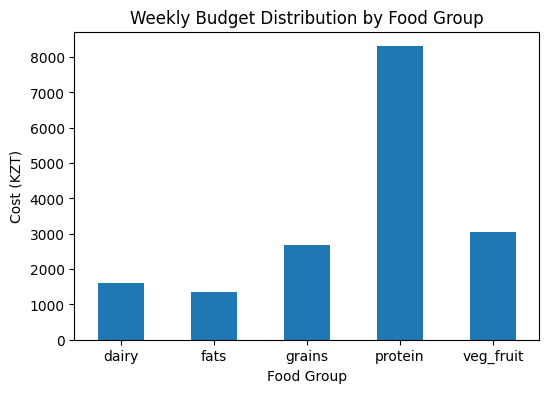

In [33]:
import matplotlib.pyplot as plt

summary = (
    shopping_list(basket_budget)
    .groupby("Group")["Total Cost (KZT)"]
    .sum()
)

plt.figure(figsize=(6,4))
summary.plot(kind="bar")
plt.title("Weekly Budget Distribution by Food Group")
plt.ylabel("Cost (KZT)")
plt.xlabel("Food Group")
plt.xticks(rotation=0)
plt.show()


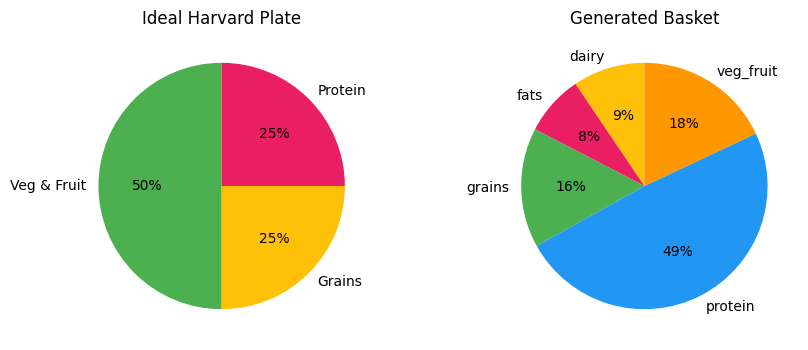

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(10,4))

# Data for Harvard Plate
harvard_labels = ["Veg & Fruit", "Grains", "Protein"]
harvard_sizes = [50, 25, 25]
harvard_colors = ['#4CAF50', '#FFC107', '#E91E63'] # Green, Amber, Pink

# Data for Generated Basket
labels = summary.index.tolist()
sizes = summary.values.tolist()
colors = ['#FFC107', '#E91E63', '#4CAF50', '#2196F3', '#FF9800'] # Example colors

axs[0].pie(harvard_sizes, labels=harvard_labels, autopct="%1.0f%%", startangle=90, colors=harvard_colors)
axs[0].set_title("Ideal Harvard Plate")

axs[1].pie(sizes, labels=labels, autopct="%1.0f%%", startangle=90, colors=colors)
axs[1].set_title("Generated Basket")

plt.show()

In [36]:
import numpy as np
import pandas as pd

def build_basket_with_targets(
    df,
    targets,  # dict: {"veg_fruit":0.5, "grains":0.25, "protein":0.25}
    days=7,
    grams_per_day=1200,
    tier="budget",
    n_items_per_group=5,
    add_dairy=True,
    dairy_g_per_day=200,
    add_fats=True,
    fats_g_per_day=15,
    seed=42
):
    # safety check
    s = sum(targets.values())
    if abs(s - 1.0) > 1e-6:
        raise ValueError(f"Targets must sum to 1.0, got {s}")

    np.random.seed(seed)
    rows = []
    total_g = days * grams_per_day

    # --- main plate groups ---
    for group, share in targets.items():
        need_g = total_g * share
        gdf = df[df["plate_group"] == group].dropna(subset=["price_per_100g", "Price", "Package Weight in g"])
        if len(gdf) == 0:
            print(f"⚠️ No items for group: {group}")
            continue

        items = pick_items(gdf, tier, n_items_per_group, seed=seed)  # uses your current pick_items()
        grams_each = need_g / len(items)

        for _, r in items.iterrows():
            pack_w = r["Package Weight in g"]
            packages = int(np.ceil(grams_each / pack_w))
            cost = packages * r["Price"]

            rows.append({
                "plate_group": group,
                "Product Name": r["Product Name"],
                "Store": r["Store"],
                "grams_needed": round(grams_each, 0),
                "package_weight_g": float(pack_w),
                "packages_to_buy": int(packages),
                "price_kzt": float(r["Price"]),
                "cost_kzt": float(cost),
                "price_per_100g": float(round(r["price_per_100g"], 2)),
                "Protein per 100g": float(r.get("Protein per 100g", np.nan)),
                "Calories per 100g": float(r.get("Calories per 100g", np.nan)),
            })

    # --- optional dairy ---
    if add_dairy:
        need_g = days * dairy_g_per_day
        gdf = df[df["plate_group"] == "dairy"].dropna(subset=["price_per_100g", "Price", "Package Weight in g"])
        if len(gdf) > 0:
            items = pick_items(gdf, tier, n=3, seed=seed)
            grams_each = need_g / len(items)
            for _, r in items.iterrows():
                pack_w = r["Package Weight in g"]
                packages = int(np.ceil(grams_each / pack_w))
                cost = packages * r["Price"]
                rows.append({
                    "plate_group": "dairy",
                    "Product Name": r["Product Name"],
                    "Store": r["Store"],
                    "grams_needed": round(grams_each, 0),
                    "package_weight_g": float(pack_w),
                    "packages_to_buy": int(packages),
                    "price_kzt": float(r["Price"]),
                    "cost_kzt": float(cost),
                    "price_per_100g": float(round(r["price_per_100g"], 2)),
                    "Protein per 100g": float(r.get("Protein per 100g", np.nan)),
                    "Calories per 100g": float(r.get("Calories per 100g", np.nan)),
                })

    # --- optional fats ---
    if add_fats:
        need_g = days * fats_g_per_day
        gdf = df[df["plate_group"] == "fats"].dropna(subset=["price_per_100g", "Price", "Package Weight in g"])
        if len(gdf) > 0:
            items = pick_items(gdf, tier, n=1, seed=seed)
            grams_each = need_g
            for _, r in items.iterrows():
                pack_w = r["Package Weight in g"]
                packages = int(np.ceil(grams_each / pack_w))
                cost = packages * r["Price"]
                rows.append({
                    "plate_group": "fats",
                    "Product Name": r["Product Name"],
                    "Store": r["Store"],
                    "grams_needed": round(grams_each, 0),
                    "package_weight_g": float(pack_w),
                    "packages_to_buy": int(packages),
                    "price_kzt": float(r["Price"]),
                    "cost_kzt": float(cost),
                    "price_per_100g": float(round(r["price_per_100g"], 2)),
                    "Protein per 100g": float(r.get("Protein per 100g", np.nan)),
                    "Calories per 100g": float(r.get("Calories per 100g", np.nan)),
                })

    basket = pd.DataFrame(rows).sort_values(["plate_group", "cost_kzt"], ascending=[True, False])
    total_cost = float(basket["cost_kzt"].sum())
    return basket, total_cost


In [37]:
import numpy as np
import pandas as pd

def run_sensitivity(df, tier="budget", days=7, grams_per_day=1200, grains_fixed=0.25,
                    protein_grid=np.arange(0.20, 0.36, 0.05),
                    include_dairy=True, include_fats=True):
    results = []
    baskets = {}

    for p in protein_grid:
        v = 1.0 - grains_fixed - p
        if v <= 0:
            continue

        targets = {"veg_fruit": v, "grains": grains_fixed, "protein": p}

        basket, cost = build_basket_with_targets(
            df,
            targets=targets,
            days=days,
            grams_per_day=grams_per_day,
            tier=tier,
            add_dairy=include_dairy,
            add_fats=include_fats
        )

        # optional: compute total protein grams in basket (approx)
        # protein grams = sum( grams_needed * (protein_per_100g/100) )
        basket["protein_g_item"] = basket["grams_needed"] * (basket["Protein per 100g"] / 100.0)
        total_protein_g = float(basket["protein_g_item"].sum(skipna=True))

        results.append({
            "protein_share": p,
            "veg_share": v,
            "grains_share": grains_fixed,
            "weekly_cost_kzt": cost,
            "approx_total_protein_g": total_protein_g
        })
        baskets[p] = basket

    return pd.DataFrame(results).sort_values("protein_share"), baskets

sens_df, sens_baskets = run_sensitivity(df, tier="budget")
sens_df


,protein_share,veg_share,grains_share,weekly_cost_kzt,approx_total_protein_g
0,0.20,0.55,0.25,16975.0,648.787
1,0.25,0.50,0.25,16975.0,720.523
2,0.30,0.45,0.25,16975.0,792.259
3,0.35,0.40,0.25,16793.0,863.995


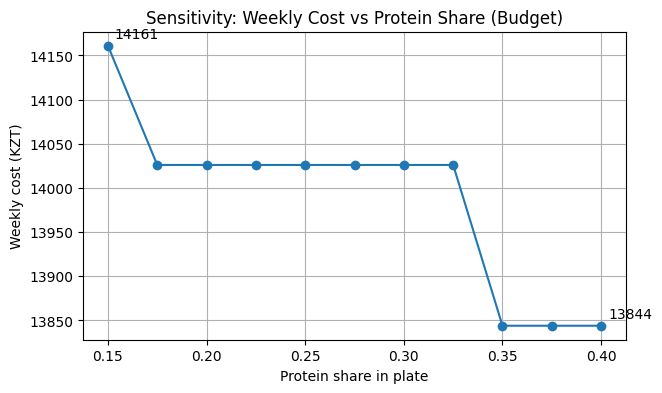

In [44]:
sens_df, _ = run_sensitivity(
    df,
    tier="budget",
    protein_grid=np.arange(0.15, 0.41, 0.025),  # больше точек
    include_dairy=False,
    include_fats=False
)

plt.figure(figsize=(7,4))
plt.plot(sens_df["protein_share"], sens_df["weekly_cost_kzt"], marker="o")
plt.title("Sensitivity: Weekly Cost vs Protein Share (Budget)")
plt.xlabel("Protein share in plate")
plt.ylabel("Weekly cost (KZT)")
plt.grid(True)

# подпишем крайние точки (выглядит профессионально)
for i in [0, len(sens_df)-1]:
    x = sens_df.iloc[i]["protein_share"]
    y = sens_df.iloc[i]["weekly_cost_kzt"]
    plt.annotate(f"{int(y)}", (x, y), textcoords="offset points", xytext=(5,5))

plt.show()


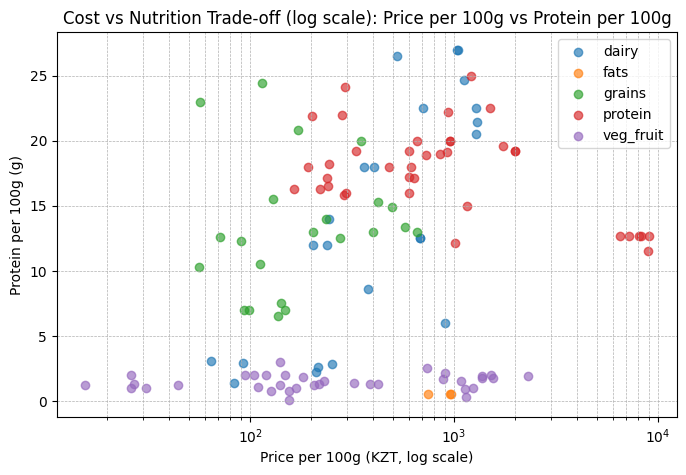

In [42]:
plot_df = df.dropna(subset=["price_per_100g", "Protein per 100g", "plate_group"]).copy()

# уберём явные “битые” строки
plot_df = plot_df[(plot_df["price_per_100g"] > 0) & (plot_df["price_per_100g"] < 20000)]
plot_df = plot_df[(plot_df["Protein per 100g"] >= 0) & (plot_df["Protein per 100g"] <= 80)]  # 160 — подозрительно

plt.figure(figsize=(8,5))
for grp, g in plot_df.groupby("plate_group"):
    plt.scatter(g["price_per_100g"], g["Protein per 100g"], label=grp, alpha=0.65)

plt.xscale("log")  # ✅ ключ к красоте
plt.title("Cost vs Nutrition Trade-off (log scale): Price per 100g vs Protein per 100g")
plt.xlabel("Price per 100g (KZT, log scale)")
plt.ylabel("Protein per 100g (g)")
plt.legend()
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()


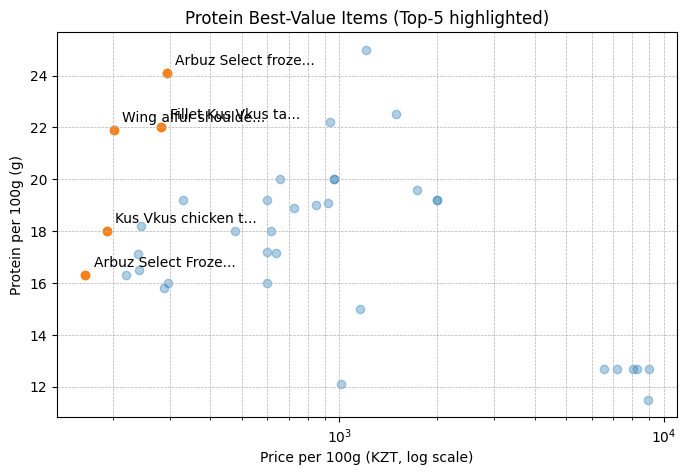

,Product Name,Store,price_per_100g,Protein per 100g,value_score
102,Wing alfur shoulder part of the chicken-broile...,Arbuz.kz,201.600000,21.9,0.108631
99,Arbuz Select Frozen Chicken Thigh,Arbuz.kz,164.571429,16.3,0.099045
98,Kus Vkus chicken thigh broiler on the substrat...,Arbuz.kz,192.100000,18.0,0.093701
92,Arbuz Select frozen chicken fillet,Arbuz.kz,293.571429,24.1,0.082092
91,Fillet Kus Vkus taste of a chicken chicken chi...,Arbuz.kz,282.800000,22.0,0.077793


In [43]:
prot = plot_df[plot_df["plate_group"]=="protein"].copy()
prot["value_score"] = prot["Protein per 100g"] / prot["price_per_100g"]

topv = prot.sort_values("value_score", ascending=False).head(5)

plt.figure(figsize=(8,5))
plt.scatter(prot["price_per_100g"], prot["Protein per 100g"], alpha=0.35)
plt.scatter(topv["price_per_100g"], topv["Protein per 100g"], alpha=0.95)

plt.xscale("log")
plt.title("Protein Best-Value Items (Top-5 highlighted)")
plt.xlabel("Price per 100g (KZT, log scale)")
plt.ylabel("Protein per 100g (g)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

for _, r in topv.iterrows():
    name = str(r["Product Name"])
    short = (name[:18] + "...") if len(name) > 21 else name
    plt.annotate(short, (r["price_per_100g"], r["Protein per 100g"]),
                 textcoords="offset points", xytext=(6,6))

plt.show()

display(topv[["Product Name","Store","price_per_100g","Protein per 100g","value_score"]])
